# Analiza wyników – Etap 3

Notatnik agreguje wyniki czterech modeli klasyfikacji sentymentu (SVM + TF-IDF, LSTM, MiniLM, DistilBERT) ewaluowanych w protokole cross-domain (4 domeny treningowe × 4 domeny testowe × 5 foldów = 80 punktów pomiarowych na model) i generuje tabele oraz wykresy potrzebne do odpowiedzi na trzy pytania badawcze:

1. **RQ1**: Jak duży jest spadek skuteczności klasyfikacji sentymentu OOD vs IND?
2. **RQ2**: Czy modele oparte na uwadze (MiniLM, DistilBERT) generalizują lepiej niż klasyczne (SVM + TF-IDF, LSTM)?
3. **RQ3**: W jakim stopniu charakterystyka domeny źródłowej (rozmiar, balans klas) wpływa na zdolność generalizacyjną?

Wszystkie tabele zapisywane są do `analysis/tables/` (CSV + fragmenty `.tex` do `\input`), figury do `analysis/figures/` (PDF + PNG).

In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
ANALYSIS_DIR = ROOT / "analysis"
FIG_DIR = ANALYSIS_DIR / "figures"
TAB_DIR = ANALYSIS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["SVM", "LSTM", "MiniLM", "DistilBERT"]
DOMAINS = ["imdb", "rotten", "amazon", "yelp"]
DOMAIN_LABELS = {"imdb": "IMDb", "rotten": "Rotten", "amazon": "Amazon", "yelp": "Yelp"}
DOMAIN_BALANCE = {"imdb": "zbalansowana", "rotten": "zbalansowana",
                  "amazon": "niezbalansowana", "yelp": "niezbalansowana"}
DOMAIN_SIZE = {"imdb": 50000, "rotten": 50000, "amazon": 21055, "yelp": 10000}

MODEL_PALETTE = {
    "SVM": "#4C78A8",
    "LSTM": "#F58518",
    "MiniLM": "#54A24B",
    "DistilBERT": "#E45756",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["pdf.fonttype"] = 42

print(f"ROOT      = {ROOT}")
print(f"FIG_DIR   = {FIG_DIR}")
print(f"TAB_DIR   = {TAB_DIR}")

ROOT      = C:\Users\katszcze\Documents\w_PythonProjects\nlp-out-of-domain-analysis
FIG_DIR   = C:\Users\katszcze\Documents\w_PythonProjects\nlp-out-of-domain-analysis\analysis\figures
TAB_DIR   = C:\Users\katszcze\Documents\w_PythonProjects\nlp-out-of-domain-analysis\analysis\tables


## 1. Wczytanie wyników i budowa wspólnej ramki danych

Wszystkie cztery pliki `*_ood_results.csv` mają identyczny schemat kolumn (`train_domain`, `test_domain`, `fold`, `accuracy`, `precision`, `recall`, `f1`, `eval_type`). Łączymy je w jedną ramkę `long_df` z dodatkową kolumną `model`.

In [2]:
RESULT_FILES = {
    "SVM":        ROOT / "svm"        / "results" / "svm_ood_results.csv",
    "LSTM":       ROOT / "lstm"       / "results" / "ood_results.csv",
    "MiniLM":     ROOT / "minilm"     / "results" / "minilm_ood_results.csv",
    "DistilBERT": ROOT / "distilbert" / "results" / "distilbert_ood_results.csv",
}

frames = []
for model, path in RESULT_FILES.items():
    df = pd.read_csv(path)
    df["model"] = model
    frames.append(df)

long_df = pd.concat(frames, ignore_index=True)
long_df["model"] = pd.Categorical(long_df["model"], categories=MODELS, ordered=True)
long_df["train_domain"] = pd.Categorical(long_df["train_domain"], categories=DOMAINS, ordered=True)
long_df["test_domain"] = pd.Categorical(long_df["test_domain"], categories=DOMAINS, ordered=True)

print(f"long_df shape: {long_df.shape}")
long_df.head()

long_df shape: (320, 9)


,train_domain,test_domain,fold,accuracy,precision,recall,f1,eval_type,model
0,imdb,imdb,1,0.907300,0.904790,0.910400,0.907586,IND,SVM
1,imdb,rotten,1,0.723294,0.703719,0.771360,0.735988,OOD,SVM
2,imdb,amazon,1,0.762907,0.608349,0.717226,0.658316,OOD,SVM
3,imdb,yelp,1,0.840000,0.947074,0.855598,0.899015,OOD,SVM
4,imdb,imdb,2,0.908000,0.903960,0.913000,0.908458,IND,SVM


In [3]:
counts = long_df.groupby(["model", "train_domain", "test_domain"], observed=True).size()
assert (counts == 5).all(), "Każda komórka (model, train, test) powinna mieć dokładnie 5 foldów"

mismatch = long_df[
    ((long_df["train_domain"] == long_df["test_domain"]) & (long_df["eval_type"] != "IND")) |
    ((long_df["train_domain"] != long_df["test_domain"]) & (long_df["eval_type"] != "OOD"))
]
assert mismatch.empty, "Flagi IND/OOD niespójne z parami (train, test)"

print(f"Liczba pomiarów: {len(long_df)} (oczekiwane 4 modele × 80 = 320)")
print(f"Liczba unikatowych par (model, train, test): {len(counts)} (oczekiwane 64)")
print("Sanity check: OK")

Liczba pomiarów: 320 (oczekiwane 4 modele × 80 = 320)
Liczba unikatowych par (model, train, test): 64 (oczekiwane 64)
Sanity check: OK


## 2. RQ1 — Spadek skuteczności OOD vs IND

Dla każdej kombinacji modelu i domeny treningowej:

- liczymy **średnie IND** (F1, accuracy) z pięciu foldów na zbiorze docelowym równym domenie źródłowej,
- liczymy **średnie OOD** z pięciu foldów × trzech pozostałych domen testowych (15 pomiarów),
- liczymy **bezwzględny spadek** Δ = IND − OOD oraz **względny spadek** (Δ / IND).

Wartości raportujemy jako $\mu \pm \sigma$. Wynik trafia do `tables/rq1_ind_vs_ood.{csv,tex}`, wraz z heatmapami pełnej macierzy 4×4 oraz słupkowym wykresem średniego spadku per model.

In [4]:
def agg_mean_std(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.DataFrame:
    return (df.groupby(group_cols, observed=True)[metric]
              .agg(["mean", "std"])
              .reset_index())

ind_per_model_train = agg_mean_std(
    long_df[long_df["eval_type"] == "IND"], "f1", ["model", "train_domain"]
).rename(columns={"mean": "ind_f1_mean", "std": "ind_f1_std"})

ood_per_model_train = agg_mean_std(
    long_df[long_df["eval_type"] == "OOD"], "f1", ["model", "train_domain"]
).rename(columns={"mean": "ood_f1_mean", "std": "ood_f1_std"})

rq1 = ind_per_model_train.merge(ood_per_model_train, on=["model", "train_domain"])
rq1["abs_drop"] = rq1["ind_f1_mean"] - rq1["ood_f1_mean"]
rq1["rel_drop_pct"] = 100.0 * rq1["abs_drop"] / rq1["ind_f1_mean"]

rq1_acc_ind = agg_mean_std(long_df[long_df["eval_type"] == "IND"], "accuracy",
                            ["model", "train_domain"]).rename(columns={"mean": "ind_acc_mean", "std": "ind_acc_std"})
rq1_acc_ood = agg_mean_std(long_df[long_df["eval_type"] == "OOD"], "accuracy",
                            ["model", "train_domain"]).rename(columns={"mean": "ood_acc_mean", "std": "ood_acc_std"})
rq1 = rq1.merge(rq1_acc_ind, on=["model", "train_domain"]).merge(rq1_acc_ood, on=["model", "train_domain"])
rq1["abs_drop_acc"] = rq1["ind_acc_mean"] - rq1["ood_acc_mean"]

rq1_csv = rq1.copy()
rq1_csv.to_csv(TAB_DIR / "rq1_ind_vs_ood.csv", index=False)
rq1

,model,train_domain,ind_f1_mean,ind_f1_std,ood_f1_mean,ood_f1_std,abs_drop,rel_drop_pct,ind_acc_mean,ind_acc_std,ood_acc_mean,ood_acc_std,abs_drop_acc
0,SVM,imdb,0.908347,0.002492,0.767082,0.103562,0.141265,15.551909,0.907860,0.002565,0.774505,0.053597,0.133355
1,SVM,rotten,0.777647,0.005176,0.722964,0.111741,0.054683,7.031855,0.777355,0.004867,0.762734,0.068049,0.014621
2,SVM,amazon,0.883000,0.003844,0.695167,0.162219,0.187833,21.272145,0.926241,0.002626,0.696782,0.122350,0.229458
3,SVM,yelp,0.947140,0.003527,0.733373,0.040013,0.213767,22.569744,0.911200,0.005837,0.697200,0.110255,0.214000
4,LSTM,imdb,0.882648,0.005589,0.723998,0.108642,0.158650,17.974296,0.882040,0.003636,0.736162,0.037671,0.145878
5,LSTM,rotten,0.766908,0.007257,0.649058,0.094715,0.117851,15.366999,0.775315,0.005293,0.691626,0.066252,0.083690
6,LSTM,amazon,0.866637,0.012122,0.661868,0.152395,0.204768,23.627917,0.916552,0.005515,0.670836,0.101845,0.245716
7,LSTM,yelp,0.933486,0.007328,0.694642,0.032411,0.238844,25.586260,0.886800,0.012478,0.640497,0.091007,0.246303
8,MiniLM,imdb,0.824998,0.001539,0.745491,0.138703,0.079507,9.637251,0.824560,0.001252,0.724044,0.111246,0.100516
9,MiniLM,rotten,0.735735,0.007623,0.751012,0.100086,-0.015277,-2.076448,0.736495,0.007305,0.792932,0.016490,-0.056437


In [5]:
def fmt_mean_std(mu: float, sigma: float, digits: int = 3) -> str:
    return f"{mu:.{digits}f} $\\pm$ {sigma:.{digits}f}"

def fmt_signed(value: float, digits: int = 3) -> str:
    sign = "" if value >= 0 else "$-$"
    return f"{sign}{abs(value):.{digits}f}"

rq1_tex_rows = []
for _, r in rq1.iterrows():
    rq1_tex_rows.append([
        r["model"],
        DOMAIN_LABELS[r["train_domain"]],
        fmt_mean_std(r["ind_f1_mean"], r["ind_f1_std"]),
        fmt_mean_std(r["ood_f1_mean"], r["ood_f1_std"]),
        fmt_signed(r["abs_drop"]),
        f"{r['rel_drop_pct']:.1f}\\%",
    ])

rq1_tex_df = pd.DataFrame(rq1_tex_rows, columns=[
    "Model", "Domena tren.", "F1 IND", "F1 OOD", "$\\Delta$ F1", "$\\Delta$/IND"
])

tex = (
    "\\begin{tabularx}{\\textwidth}{@{}llYYYY@{}}\n"
    "\\hline\n"
    "Model & Dom. tren. & F1 IND ($\\mu\\pm\\sigma$) & F1 OOD ($\\mu\\pm\\sigma$) & "
    "$\\Delta$ F1 & $\\Delta$/IND \\\\\n"
    "\\hline\n"
)
prev_model = None
for row in rq1_tex_rows:
    model_cell = row[0] if row[0] != prev_model else ""
    tex += f"{model_cell} & {row[1]} & {row[2]} & {row[3]} & {row[4]} & {row[5]} \\\\\n"
    prev_model = row[0]
tex += "\\hline\n\\end{tabularx}\n"

(TAB_DIR / "rq1_ind_vs_ood.tex").write_text(tex, encoding="utf-8")
print(tex[:600] + "...")
rq1_tex_df

\begin{tabularx}{\textwidth}{@{}llYYYY@{}}
\hline
Model & Dom. tren. & F1 IND ($\mu\pm\sigma$) & F1 OOD ($\mu\pm\sigma$) & $\Delta$ F1 & $\Delta$/IND \\
\hline
SVM & IMDb & 0.908 $\pm$ 0.002 & 0.767 $\pm$ 0.104 & 0.141 & 15.6\% \\
 & Rotten & 0.778 $\pm$ 0.005 & 0.723 $\pm$ 0.112 & 0.055 & 7.0\% \\
 & Amazon & 0.883 $\pm$ 0.004 & 0.695 $\pm$ 0.162 & 0.188 & 21.3\% \\
 & Yelp & 0.947 $\pm$ 0.004 & 0.733 $\pm$ 0.040 & 0.214 & 22.6\% \\
LSTM & IMDb & 0.883 $\pm$ 0.006 & 0.724 $\pm$ 0.109 & 0.159 & 18.0\% \\
 & Rotten & 0.767 $\pm$ 0.007 & 0.649 $\pm$ 0.095 & 0.118 & 15.4\% \\
 & Amazon & 0.867 $\...


,Model,Domena tren.,F1 IND,F1 OOD,$\Delta$ F1,$\Delta$/IND
0,SVM,IMDb,0.908 $\pm$ 0.002,0.767 $\pm$ 0.104,0.141,15.6\%
1,SVM,Rotten,0.778 $\pm$ 0.005,0.723 $\pm$ 0.112,0.055,7.0\%
2,SVM,Amazon,0.883 $\pm$ 0.004,0.695 $\pm$ 0.162,0.188,21.3\%
3,SVM,Yelp,0.947 $\pm$ 0.004,0.733 $\pm$ 0.040,0.214,22.6\%
4,LSTM,IMDb,0.883 $\pm$ 0.006,0.724 $\pm$ 0.109,0.159,18.0\%
5,LSTM,Rotten,0.767 $\pm$ 0.007,0.649 $\pm$ 0.095,0.118,15.4\%
6,LSTM,Amazon,0.867 $\pm$ 0.012,0.662 $\pm$ 0.152,0.205,23.6\%
7,LSTM,Yelp,0.933 $\pm$ 0.007,0.695 $\pm$ 0.032,0.239,25.6\%
8,MiniLM,IMDb,0.825 $\pm$ 0.002,0.745 $\pm$ 0.139,0.080,9.6\%
9,MiniLM,Rotten,0.736 $\pm$ 0.008,0.751 $\pm$ 0.100,$-$0.015,-2.1\%


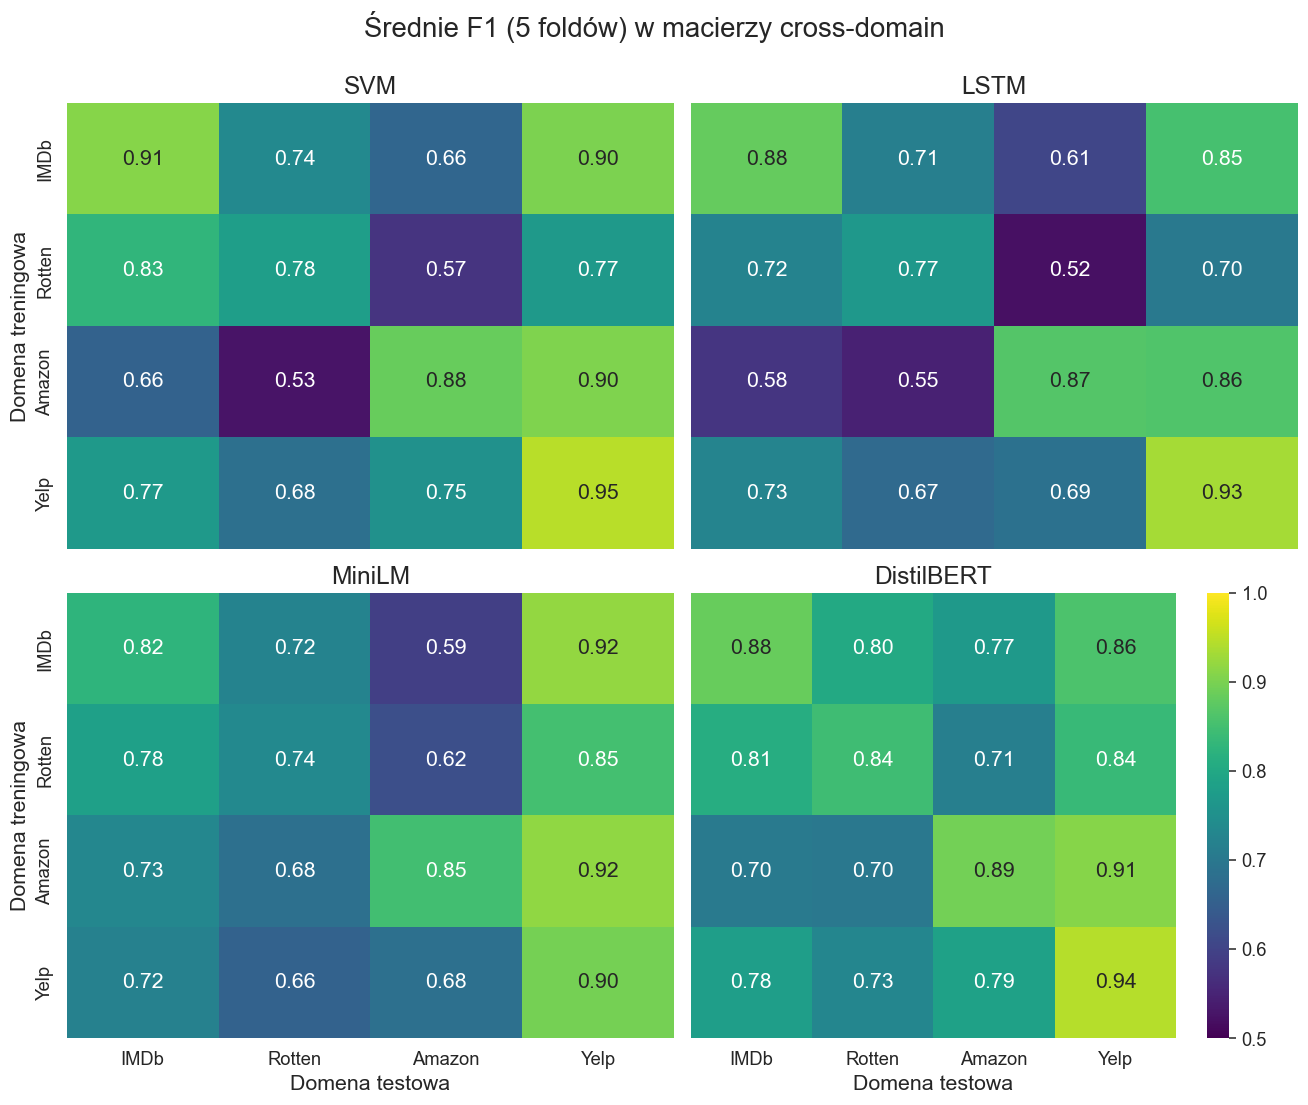

In [6]:
cell_mean = (long_df.groupby(["model", "train_domain", "test_domain"], observed=True)["f1"]
                    .mean()
                    .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()
last_idx = len(MODELS) - 1
for idx, (ax, model) in enumerate(zip(axes_flat, MODELS)):
    pivot = (cell_mean[cell_mean["model"] == model]
             .pivot(index="train_domain", columns="test_domain", values="f1")
             .reindex(index=DOMAINS, columns=DOMAINS))
    sns.heatmap(pivot, annot=True, fmt=".2f", vmin=0.5, vmax=1.0,
                cmap="viridis", cbar=(idx == last_idx),
                xticklabels=[DOMAIN_LABELS[d] for d in DOMAINS],
                yticklabels=[DOMAIN_LABELS[d] for d in DOMAINS],
                annot_kws={"fontsize": 14},
                ax=ax)
    ax.set_title(model, fontsize=16)
    ax.set_xlabel("Domena testowa" if idx >= 2 else "", fontsize=14)
    ax.set_ylabel("Domena treningowa" if idx % 2 == 0 else "", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    if idx == last_idx:
        cbar = ax.collections[0].colorbar
        if cbar is not None:
            cbar.ax.tick_params(labelsize=12)

fig.suptitle("Średnie F1 (5 foldów) w macierzy cross-domain", fontsize=18, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_heatmap_f1.pdf")
fig.savefig(FIG_DIR / "rq1_heatmap_f1.png", dpi=160)
plt.show()

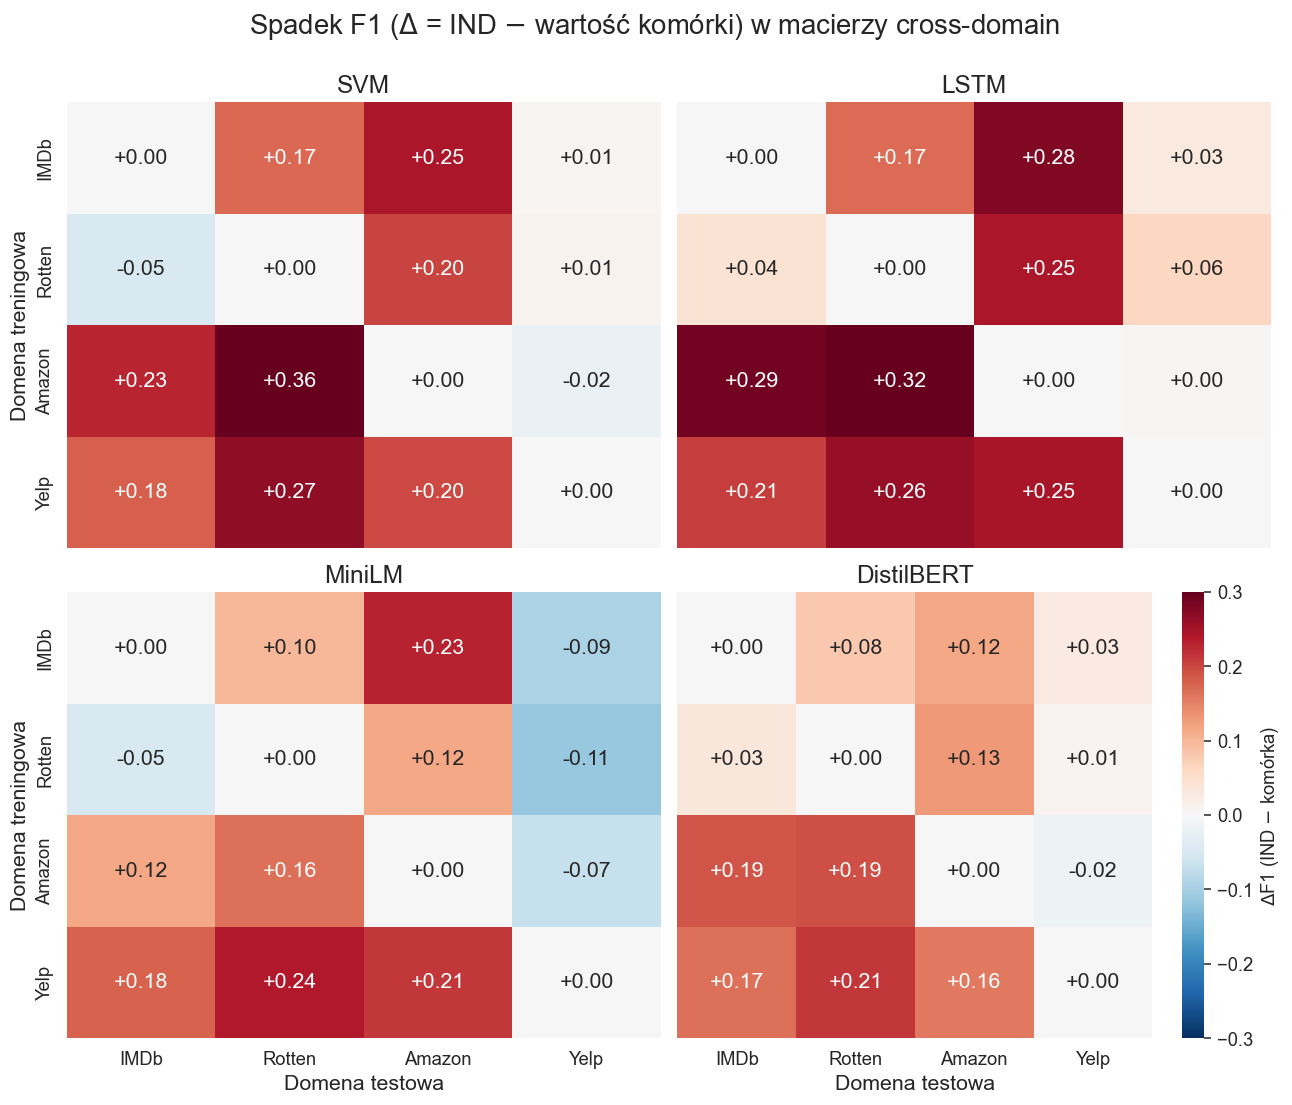

In [7]:
ind_baseline = (rq1[["model", "train_domain", "ind_f1_mean"]]
                .set_index(["model", "train_domain"]))

delta_df = cell_mean.merge(ind_baseline,
                           left_on=["model", "train_domain"],
                           right_index=True)
delta_df["delta"] = delta_df["ind_f1_mean"] - delta_df["f1"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()
last_idx = len(MODELS) - 1
vlim = 0.30
for idx, (ax, model) in enumerate(zip(axes_flat, MODELS)):
    pivot = (delta_df[delta_df["model"] == model]
             .pivot(index="train_domain", columns="test_domain", values="delta")
             .reindex(index=DOMAINS, columns=DOMAINS))
    sns.heatmap(pivot, annot=True, fmt="+.2f", vmin=-vlim, vmax=vlim,
                center=0, cmap="RdBu_r", cbar=(idx == last_idx),
                xticklabels=[DOMAIN_LABELS[d] for d in DOMAINS],
                yticklabels=[DOMAIN_LABELS[d] for d in DOMAINS],
                annot_kws={"fontsize": 14},
                ax=ax)
    ax.set_title(model, fontsize=16)
    ax.set_xlabel("Domena testowa" if idx >= 2 else "", fontsize=14)
    ax.set_ylabel("Domena treningowa" if idx % 2 == 0 else "", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    if idx == last_idx:
        cbar = ax.collections[0].colorbar
        if cbar is not None:
            cbar.ax.tick_params(labelsize=12)
            cbar.set_label(r"$\Delta$F1 (IND $-$ komórka)", fontsize=12)

fig.suptitle(r"Spadek F1 ($\Delta$ = IND $-$ wartość komórki) w macierzy cross-domain",
             fontsize=18, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_heatmap_delta.pdf")
fig.savefig(FIG_DIR / "rq1_heatmap_delta.png", dpi=160)
plt.show()

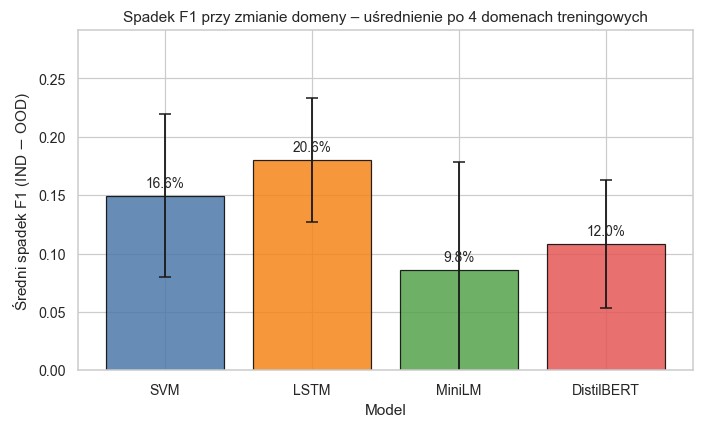

,model,abs_drop_mean,abs_drop_std,rel_drop_mean
0,SVM,0.149387,0.069899,16.606413
1,LSTM,0.180028,0.052898,20.638868
2,MiniLM,0.086069,0.092729,9.821346
3,DistilBERT,0.108353,0.054929,11.970886


In [8]:
avg_drop = (rq1.groupby("model", observed=True)
              .agg(abs_drop_mean=("abs_drop", "mean"),
                   abs_drop_std=("abs_drop", "std"),
                   rel_drop_mean=("rel_drop_pct", "mean"))
              .reset_index())
avg_drop["model"] = pd.Categorical(avg_drop["model"], categories=MODELS, ordered=True)
avg_drop = avg_drop.sort_values("model")

fig, ax = plt.subplots(figsize=(6.5, 4.0))
colors = [MODEL_PALETTE[m] for m in avg_drop["model"]]
bars = ax.bar(avg_drop["model"], avg_drop["abs_drop_mean"],
              yerr=avg_drop["abs_drop_std"], capsize=4, color=colors, edgecolor="black", alpha=0.85)
for bar, rel in zip(bars, avg_drop["rel_drop_mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rel:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Średni spadek F1 (IND $-$ OOD)")
ax.set_xlabel("Model")
ax.set_title("Spadek F1 przy zmianie domeny – uśrednienie po 4 domenach treningowych")
ax.set_ylim(0, max(avg_drop["abs_drop_mean"] + avg_drop["abs_drop_std"]) * 1.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_avg_drop.pdf")
fig.savefig(FIG_DIR / "rq1_avg_drop.png", dpi=160)
plt.show()
avg_drop

## 3. RQ2 — Porównanie architektur (klasyczne vs uwagowe)

Ranking modeli po średnim **F1 OOD** (60 pomiarów na model: 4 domeny treningowe × 3 OOD domeny testowe × 5 foldów). Testy istotności:

- **paired t-test** dopasowany w jednostkach `(train_domain, test_domain, fold)` zgodnie z wytycznymi W1_PJN (slajd 33),
- **test Wilcoxona** jako odporne na łamanie założenia normalności (n = 60 par),
- korekta **Bonferroniego** dla 6 par modeli (C(4,2)).

In [9]:
ood_only = long_df[long_df["eval_type"] == "OOD"].copy()

ranking = (ood_only.groupby("model", observed=True)["f1"]
           .agg(["mean", "std", "median"])
           .rename(columns={"mean": "ood_f1_mean", "std": "ood_f1_std", "median": "ood_f1_median"})
           .reindex(MODELS))

ind_mean = (long_df[long_df["eval_type"] == "IND"]
            .groupby("model", observed=True)["f1"]
            .mean()
            .rename("ind_f1_mean")
            .reindex(MODELS))

ranking["ind_f1_mean"] = ind_mean
ranking["overall_drop"] = ranking["ind_f1_mean"] - ranking["ood_f1_mean"]
ranking = ranking.reset_index().rename(columns={"index": "model"})

ranking_tex = (
    "\\begin{tabularx}{\\textwidth}{@{}lYYYY@{}}\n"
    "\\hline\n"
    "Model & F1 IND ($\\mu$) & F1 OOD ($\\mu\\pm\\sigma$) & Mediana F1 OOD & "
    "Spadek $\\Delta$ \\\\\n"
    "\\hline\n"
)
for _, r in ranking.iterrows():
    ranking_tex += (
        f"{r['model']} & {r['ind_f1_mean']:.3f} & "
        f"{fmt_mean_std(r['ood_f1_mean'], r['ood_f1_std'])} & "
        f"{r['ood_f1_median']:.3f} & {fmt_signed(r['overall_drop'])} \\\\\n"
    )
ranking_tex += "\\hline\n\\end{tabularx}\n"
(TAB_DIR / "rq2_ranking.tex").write_text(ranking_tex, encoding="utf-8")
ranking.to_csv(TAB_DIR / "rq2_ranking.csv", index=False)
ranking

,model,ood_f1_mean,ood_f1_std,ood_f1_median,ind_f1_mean,overall_drop
0,SVM,0.729646,0.113161,0.736519,0.879033,0.149387
1,LSTM,0.682392,0.107505,0.684115,0.862420,0.180028
2,MiniLM,0.739895,0.104106,0.723895,0.825964,0.086069
3,DistilBERT,0.783269,0.067379,0.785537,0.891621,0.108353


In [10]:
paired = (ood_only.pivot_table(index=["train_domain", "test_domain", "fold"],
                                columns="model", values="f1", observed=True)
                  .reindex(columns=MODELS)
                  .dropna())
n_pairs = len(paired)

n_comparisons = len(list(combinations(MODELS, 2)))
records = []
for m1, m2 in combinations(MODELS, 2):
    diff = paired[m1].to_numpy() - paired[m2].to_numpy()
    t_stat, t_p = stats.ttest_rel(paired[m1], paired[m2])
    try:
        w_stat, w_p = stats.wilcoxon(paired[m1], paired[m2], zero_method="wilcox")
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    records.append({
        "model_a": m1, "model_b": m2,
        "mean_diff": diff.mean(), "std_diff": diff.std(ddof=1),
        "t_stat": t_stat, "t_p": t_p,
        "t_p_bonf": min(1.0, t_p * n_comparisons),
        "w_stat": w_stat, "w_p": w_p,
        "w_p_bonf": min(1.0, (w_p * n_comparisons) if not np.isnan(w_p) else np.nan),
    })

pairwise = pd.DataFrame(records)
pairwise.to_csv(TAB_DIR / "rq2_pairwise_pvalues.csv", index=False)
print(f"n par foldów porównywanych w testach: {n_pairs}")
pairwise

n par foldów porównywanych w testach: 60


,model_a,model_b,mean_diff,std_diff,t_stat,t_p,t_p_bonf,w_stat,w_p,w_p_bonf
0,SVM,LSTM,0.047255,0.041943,8.726838,3.267471e-12,1.960483e-11,86.0,1.042465e-09,6.254792e-09
1,SVM,MiniLM,-0.010249,0.067818,-1.170603,2.464650e-01,1.000000e+00,827.0,5.171007e-01,1.000000e+00
2,SVM,DistilBERT,-0.053623,0.066231,-6.271361,4.565033e-08,2.739020e-07,225.0,3.784174e-07,2.270505e-06
3,LSTM,MiniLM,-0.057504,0.067753,-6.574182,1.416445e-08,8.498670e-08,232.0,4.956869e-07,2.974121e-06
4,LSTM,DistilBERT,-0.100877,0.063406,-12.323558,5.819872e-18,3.491923e-17,16.0,3.638914e-11,2.183348e-10
5,MiniLM,DistilBERT,-0.043374,0.069251,-4.851499,9.327496e-06,5.596497e-05,348.0,2.992598e-05,1.795559e-04


In [11]:
def fmt_p(p: float) -> str:
    if np.isnan(p):
        return "---"
    if p < 1e-3:
        return "$<$0.001"
    return f"{p:.3f}"

def fmt_p_sig(p: float) -> str:
    if np.isnan(p):
        return "---"
    base = fmt_p(p)
    if p < 0.001:
        return base + "***"
    if p < 0.01:
        return base + "**"
    if p < 0.05:
        return base + "*"
    return base

pw_tex = (
    "\\begin{tabularx}{\\textwidth}{@{}llYYYYY@{}}\n"
    "\\hline\n"
    "Model A & Model B & $\\overline{\\Delta}$F1 & "
    "$p$ (t-test) & $p$ (t, Bonf.) & $p$ (Wilcoxon) & $p$ (W, Bonf.) \\\\\n"
    "\\hline\n"
)
for _, r in pairwise.iterrows():
    pw_tex += (
        f"{r['model_a']} & {r['model_b']} & {fmt_signed(r['mean_diff'])} & "
        f"{fmt_p(r['t_p'])} & {fmt_p_sig(r['t_p_bonf'])} & "
        f"{fmt_p(r['w_p'])} & {fmt_p_sig(r['w_p_bonf'])} \\\\\n"
    )
pw_tex += "\\hline\n\\end{tabularx}\n"
(TAB_DIR / "rq2_pairwise_pvalues.tex").write_text(pw_tex, encoding="utf-8")
print(pw_tex)

\begin{tabularx}{\textwidth}{@{}llYYYYY@{}}
\hline
Model A & Model B & $\overline{\Delta}$F1 & $p$ (t-test) & $p$ (t, Bonf.) & $p$ (Wilcoxon) & $p$ (W, Bonf.) \\
\hline
SVM & LSTM & 0.047 & $<$0.001 & $<$0.001*** & $<$0.001 & $<$0.001*** \\
SVM & MiniLM & $-$0.010 & 0.246 & 1.000 & 0.517 & 1.000 \\
SVM & DistilBERT & $-$0.054 & $<$0.001 & $<$0.001*** & $<$0.001 & $<$0.001*** \\
LSTM & MiniLM & $-$0.058 & $<$0.001 & $<$0.001*** & $<$0.001 & $<$0.001*** \\
LSTM & DistilBERT & $-$0.101 & $<$0.001 & $<$0.001*** & $<$0.001 & $<$0.001*** \\
MiniLM & DistilBERT & $-$0.043 & $<$0.001 & $<$0.001*** & $<$0.001 & $<$0.001*** \\
\hline
\end{tabularx}



C:\Users\katszcze\AppData\Local\Temp\ipykernel_15832\311460330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ood_only, x="model", y="f1", order=MODELS, ax=ax,


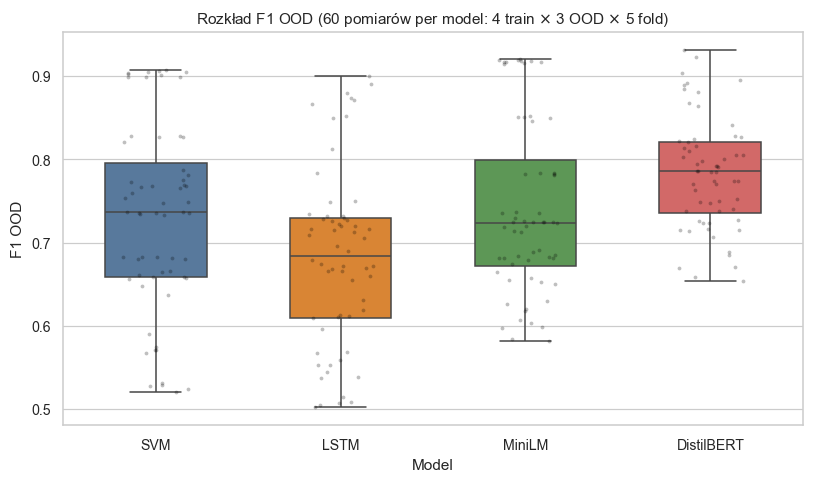

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(data=ood_only, x="model", y="f1", order=MODELS, ax=ax,
            palette=[MODEL_PALETTE[m] for m in MODELS], width=0.55, fliersize=3)
sns.stripplot(data=ood_only, x="model", y="f1", order=MODELS, ax=ax,
              color="black", alpha=0.25, size=2.5, jitter=0.18)
ax.set_ylabel("F1 OOD")
ax.set_xlabel("Model")
ax.set_title("Rozkład F1 OOD (60 pomiarów per model: 4 train $\\times$ 3 OOD $\\times$ 5 fold)")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_boxplot_f1_ood.pdf")
fig.savefig(FIG_DIR / "rq2_boxplot_f1_ood.png", dpi=160)
plt.show()

## 4. RQ3 — Wpływ charakterystyki domeny źródłowej

Pytanie sprawdza, czy bardziej liczne i zbalansowane domeny treningowe (IMDb, Rotten) produkują modele lepiej generalizujące do pozostałych domen niż mniejsze, niezbalansowane (Amazon, Yelp). Liczymy:

- średnie **F1 OOD** dla każdej pary (model, domena treningowa) — uśrednienie po 3 docelowych domenach × 5 foldach,
- agregat **F1 OOD** w podziale `balans` $\in$ {zbalansowane, niezbalansowane}.

In [13]:
rq3 = (ood_only.groupby(["model", "train_domain"], observed=True)["f1"]
              .agg(["mean", "std"])
              .reset_index()
              .rename(columns={"mean": "ood_f1_mean", "std": "ood_f1_std"}))
rq3["balans"] = rq3["train_domain"].map(DOMAIN_BALANCE)
rq3["rozmiar"] = rq3["train_domain"].map(DOMAIN_SIZE)
rq3.to_csv(TAB_DIR / "rq3_by_source_domain.csv", index=False)

rq3_tex = (
    "\\begin{tabularx}{\\textwidth}{@{}lllrY@{}}\n"
    "\\hline\n"
    "Model & Domena tren. & Balans & Rozmiar & F1 OOD ($\\mu\\pm\\sigma$) \\\\\n"
    "\\hline\n"
)
prev_model = None
for _, r in rq3.iterrows():
    model_cell = r["model"] if r["model"] != prev_model else ""
    rq3_tex += (
        f"{model_cell} & {DOMAIN_LABELS[r['train_domain']]} & {r['balans']} & "
        f"{int(r['rozmiar'])} & {fmt_mean_std(r['ood_f1_mean'], r['ood_f1_std'])} \\\\\n"
    )
    prev_model = r["model"]
rq3_tex += "\\hline\n\\end{tabularx}\n"
(TAB_DIR / "rq3_by_source_domain.tex").write_text(rq3_tex, encoding="utf-8")
rq3

,model,train_domain,ood_f1_mean,ood_f1_std,balans,rozmiar
0,SVM,imdb,0.767082,0.103562,zbalansowana,50000
1,SVM,rotten,0.722964,0.111741,zbalansowana,50000
2,SVM,amazon,0.695167,0.162219,niezbalansowana,21055
3,SVM,yelp,0.733373,0.040013,niezbalansowana,10000
4,LSTM,imdb,0.723998,0.108642,zbalansowana,50000
5,LSTM,rotten,0.649058,0.094715,zbalansowana,50000
6,LSTM,amazon,0.661868,0.152395,niezbalansowana,21055
7,LSTM,yelp,0.694642,0.032411,niezbalansowana,10000
8,MiniLM,imdb,0.745491,0.138703,zbalansowana,50000
9,MiniLM,rotten,0.751012,0.100086,zbalansowana,50000


In [14]:
balance_summary = (ood_only.assign(balans=ood_only["train_domain"].map(DOMAIN_BALANCE))
                          .groupby(["model", "balans"], observed=True)["f1"]
                          .agg(["mean", "std"])
                          .reset_index()
                          .rename(columns={"mean": "ood_f1_mean", "std": "ood_f1_std"}))
balance_summary["model"] = pd.Categorical(balance_summary["model"], categories=MODELS, ordered=True)
balance_summary = balance_summary.sort_values(["model", "balans"]).reset_index(drop=True)
balance_summary.to_csv(TAB_DIR / "rq3_balance_summary.csv", index=False)

bal_tex = (
    "\\begin{tabularx}{\\textwidth}{@{}lXY@{}}\n"
    "\\hline\n"
    "Model & Klasa domen trenuj\\k{a}cych & F1 OOD ($\\mu\\pm\\sigma$) \\\\\n"
    "\\hline\n"
)
prev_model = None
for _, r in balance_summary.iterrows():
    model_cell = r["model"] if r["model"] != prev_model else ""
    bal_tex += (
        f"{model_cell} & {r['balans']} & "
        f"{fmt_mean_std(r['ood_f1_mean'], r['ood_f1_std'])} \\\\\n"
    )
    prev_model = r["model"]
bal_tex += "\\hline\n\\end{tabularx}\n"
(TAB_DIR / "rq3_balance_summary.tex").write_text(bal_tex, encoding="utf-8")
balance_summary

,model,balans,ood_f1_mean,ood_f1_std
0,SVM,niezbalansowana,0.714270,0.117704
1,SVM,zbalansowana,0.745023,0.108207
2,LSTM,niezbalansowana,0.678255,0.109529
3,LSTM,zbalansowana,0.686528,0.107151
4,MiniLM,niezbalansowana,0.731539,0.088170
5,MiniLM,zbalansowana,0.748251,0.118875
6,DistilBERT,niezbalansowana,0.767868,0.076605
7,DistilBERT,zbalansowana,0.798670,0.053641


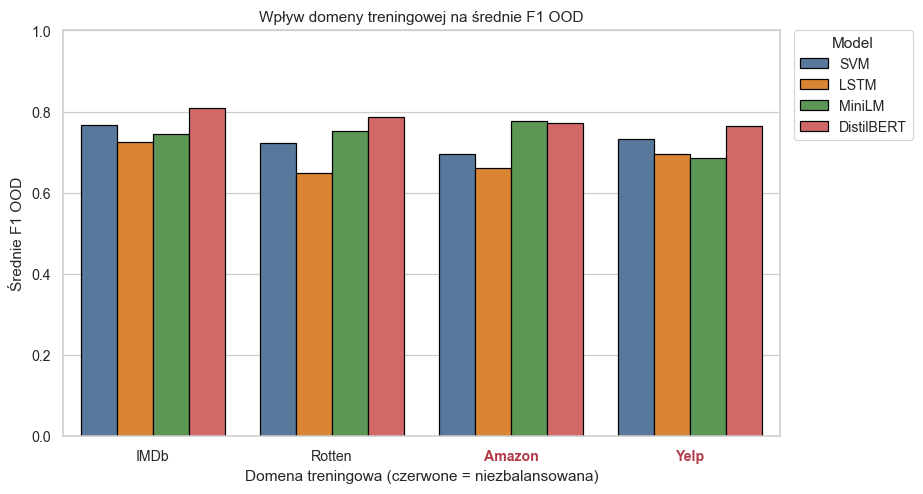

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
plot_df = rq3.copy()
plot_df["train_domain_lbl"] = plot_df["train_domain"].map(DOMAIN_LABELS)
plot_df["train_domain_lbl"] = pd.Categorical(
    plot_df["train_domain_lbl"], categories=[DOMAIN_LABELS[d] for d in DOMAINS], ordered=True
)
sns.barplot(data=plot_df, x="train_domain_lbl", y="ood_f1_mean", hue="model",
            order=[DOMAIN_LABELS[d] for d in DOMAINS], hue_order=MODELS,
            palette=MODEL_PALETTE, ax=ax, edgecolor="black")

for label_text in ax.get_xticklabels():
    label = label_text.get_text()
    domain_key = next(k for k, v in DOMAIN_LABELS.items() if v == label)
    if DOMAIN_BALANCE[domain_key] == "niezbalansowana":
        label_text.set_color("#B23A48")
        label_text.set_fontweight("bold")

ax.set_ylabel("Średnie F1 OOD")
ax.set_xlabel("Domena treningowa (czerwone = niezbalansowana)")
ax.set_title("Wpływ domeny treningowej na średnie F1 OOD")
ax.set_ylim(0, 1.0)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq3_source_domain.pdf")
fig.savefig(FIG_DIR / "rq3_source_domain.png", dpi=160)
plt.show()

## 5. Krzywe treningu (materiał uzupełniający)

Logi treningowe są zapisane w różnych schematach (LSTM/DistilBERT: per epoch; SVM/MiniLM: per fold), więc krzywe pokazujemy tylko dla modeli neuronowych z dostępnymi metrykami per epoch. Wykres ilustruje zbieżność i pomaga zdiagnozować ewentualne nadmierne dopasowanie.

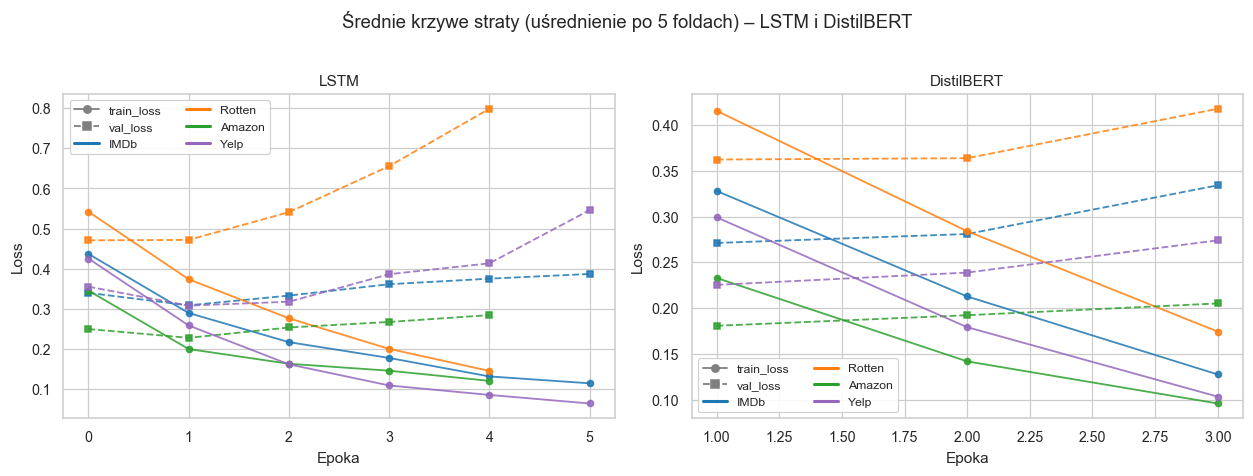

In [16]:
lstm_logs = pd.read_csv(ROOT / "lstm" / "results" / "training_logs.csv")
distil_logs = pd.read_csv(ROOT / "distilbert" / "results" / "distilbert_training_logs.csv")

lstm_logs = lstm_logs.rename(columns={"loss": "train_loss"})
lstm_curve = (lstm_logs.groupby(["train_domain", "epoch"])
                       .agg(train_loss=("train_loss", "mean"), val_loss=("val_loss", "mean"))
                       .reset_index())
lstm_curve["model"] = "LSTM"
distil_curve = (distil_logs.groupby(["train_domain", "epoch"])
                            .agg(train_loss=("train_loss", "mean"), val_loss=("val_loss", "mean"))
                            .reset_index())
distil_curve["model"] = "DistilBERT"
curves = pd.concat([lstm_curve, distil_curve], ignore_index=True)

DOMAIN_COLORS = {"imdb": "#1f77b4", "rotten": "#ff7f0e", "amazon": "#2ca02c", "yelp": "#9467bd"}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=False)
for ax, model in zip(axes, ["LSTM", "DistilBERT"]):
    sub = curves[curves["model"] == model]
    for dom in DOMAINS:
        sub_d = sub[sub["train_domain"] == dom].sort_values("epoch")
        if sub_d.empty:
            continue
        color = DOMAIN_COLORS[dom]
        ax.plot(sub_d["epoch"], sub_d["train_loss"], marker="o", linestyle="-",
                color=color, alpha=0.85, markersize=4, label=f"{DOMAIN_LABELS[dom]} (train)")
        ax.plot(sub_d["epoch"], sub_d["val_loss"], marker="s", linestyle="--",
                color=color, alpha=0.85, markersize=4, label=f"{DOMAIN_LABELS[dom]} (val)")
    ax.set_title(model)
    ax.set_xlabel("Epoka")
    ax.set_ylabel("Loss")
    handles = [
        plt.Line2D([0], [0], color="gray", linestyle="-", marker="o", label="train_loss"),
        plt.Line2D([0], [0], color="gray", linestyle="--", marker="s", label="val_loss"),
    ]
    domain_handles = [plt.Line2D([0], [0], color=DOMAIN_COLORS[d], lw=2,
                                  label=DOMAIN_LABELS[d]) for d in DOMAINS]
    ax.legend(handles=handles + domain_handles, loc="best", fontsize=8, ncol=2, framealpha=0.9)
fig.suptitle("Średnie krzywe straty (uśrednienie po 5 foldach) – LSTM i DistilBERT", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "training_curves.pdf")
fig.savefig(FIG_DIR / "training_curves.png", dpi=160)
plt.show()

## 6. Synteza – odpowiedzi na pytania badawcze

Poniższe komórki wypisują końcowe agregaty pomocne przy redakcji sekcji „Analiza wyników” i „Wnioski i podsumowanie” w raporcie.

In [17]:
summary = ranking.copy()
summary["rel_drop_pct"] = 100.0 * summary["overall_drop"] / summary["ind_f1_mean"]
print("=== RQ2 ranking (F1) ===")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== RQ1 najgorszy spadek F1 na poziomie (model, train_domain) ===")
worst = rq1.sort_values("abs_drop", ascending=False).head(5)
print(worst[["model", "train_domain", "ind_f1_mean", "ood_f1_mean", "abs_drop", "rel_drop_pct"]]
        .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== RQ3 średnie F1 OOD wg zbalansowania ===")
print(balance_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== Istotność: pary modeli z p_Bonferroni < 0.05 (t-test) ===")
sig = pairwise[pairwise["t_p_bonf"] < 0.05][["model_a", "model_b", "mean_diff", "t_p_bonf", "w_p_bonf"]]
print(sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== RQ2 ranking (F1) ===
     model  ood_f1_mean  ood_f1_std  ood_f1_median  ind_f1_mean  overall_drop  rel_drop_pct
       SVM        0.730       0.113          0.737        0.879         0.149        16.994
      LSTM        0.682       0.108          0.684        0.862         0.180        20.875
    MiniLM        0.740       0.104          0.724        0.826         0.086        10.420
DistilBERT        0.783       0.067          0.786        0.892         0.108        12.152

=== RQ1 najgorszy spadek F1 na poziomie (model, train_domain) ===
 model train_domain  ind_f1_mean  ood_f1_mean  abs_drop  rel_drop_pct
  LSTM         yelp        0.933        0.695     0.239        25.586
   SVM         yelp        0.947        0.733     0.214        22.570
MiniLM         yelp        0.895        0.686     0.210        23.409
  LSTM       amazon        0.867        0.662     0.205        23.628
   SVM       amazon        0.883        0.695     0.188        21.272

=== RQ3 średnie F1 OOD wg z